In [69]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis

from creditcard_psp.config import RAW_DATA_DIR
input_path  = RAW_DATA_DIR / "PSP_Jan_Feb_2019.xlsx"
from creditcard_psp.dataset import load_transactions

import warnings
warnings.filterwarnings("ignore")

In [66]:
# Load Data
df = load_transactions(input_path)

# Overview structure and datatypes
print("==== Dataset Info ====")
print(df.info())

# Print first 5 and last 5 rows
print("==== Erste 5 Zeilen ====")
print(df.head(5))
print("==== Letzte 5 Zeilen ====")
print(df.tail(5))

# Statistic summary of numeric rows
print("\n==== Statistische Zusammenfassung ====")
print(df.describe())

2025-04-20 14:53:38.530 | INFO     | creditcard_psp.dataset:load_transactions:27 - Loading transactions from C:\Users\miria\creditcard_psp\data\raw\PSP_Jan_Feb_2019.xlsx
==== Dataset Info ====
<class 'pandas.core.frame.DataFrame'>
Int64Index: 50410 entries, 0 to 50409
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   tmsp        50410 non-null  datetime64[ns]
 1   country     50410 non-null  object        
 2   amount      50410 non-null  int64         
 3   success     50410 non-null  int64         
 4   PSP         50410 non-null  object        
 5   3D_secured  50410 non-null  int64         
 6   card        50410 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 3.1+ MB
None
==== Erste 5 Zeilen ====
                 tmsp  country  amount  success         PSP  3D_secured  \
0 2019-01-01 00:01:11  Germany      89        0     UK_Card           0   
1 2019-01-01 00:01

In [52]:
# Missing values
print("\n==== Fehlende Werte pro Spalte ====")
missing_values = df.isnull().sum()
print(missing_values)


==== Fehlende Werte pro Spalte ====
tmsp          0
country       0
amount        0
success       0
PSP           0
3D_secured    0
card          0
dtype: int64


In [53]:
# Count duplicates
duplicates = df.duplicated().sum()
print("\n==== Anzahl Duplikate ====")
print(duplicates)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\n==== Numerische Spalten ====")
print(numeric_cols)

object_cols = df.select_dtypes(include=[object]).columns.tolist()
print("\n==== Object Spalten ====")
print(object_cols)

# Check if columns have different spellings
print("\n==== Schreibweisen in einer Spalte ====")
print(df['country'].value_counts())
print(df['PSP'].value_counts())
print(df['card'].value_counts())


==== Anzahl Duplikate ====
81

==== Numerische Spalten ====
['amount', 'success', '3D_secured']

==== Object Spalten ====
['country', 'PSP', 'card']

==== Schreibweisen in einer Spalte ====
Germany        30233
Switzerland    10338
Austria         9839
Name: country, dtype: int64
UK_Card       26459
Simplecard    12446
Moneycard      8297
Goldcard       3208
Name: PSP, dtype: int64
Master    29002
Visa      11640
Diners     9768
Name: card, dtype: int64


In [54]:
for col in numeric_cols:
    # Calculate Z-Score per column
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    # Define outliers as Z-Score > 3
    outliers = df[z_scores > 3]
    print(f"Anzahl der Ausreißer in '{col}': {outliers.shape[0]}")

Anzahl der Ausreißer in 'amount': 83
Anzahl der Ausreißer in 'success': 0
Anzahl der Ausreißer in '3D_secured': 0


In [55]:
# Count Outliers IQR
Q1 = agg_df['amount'].quantile(0.25)
Q3 = agg_df['amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = agg_df[(agg_df['amount'] < lower) | (agg_df['amount'] > upper)]
print(f"Ausreißer nach IQR: {len(outliers_iqr)}")

Ausreißer nach IQR: 148


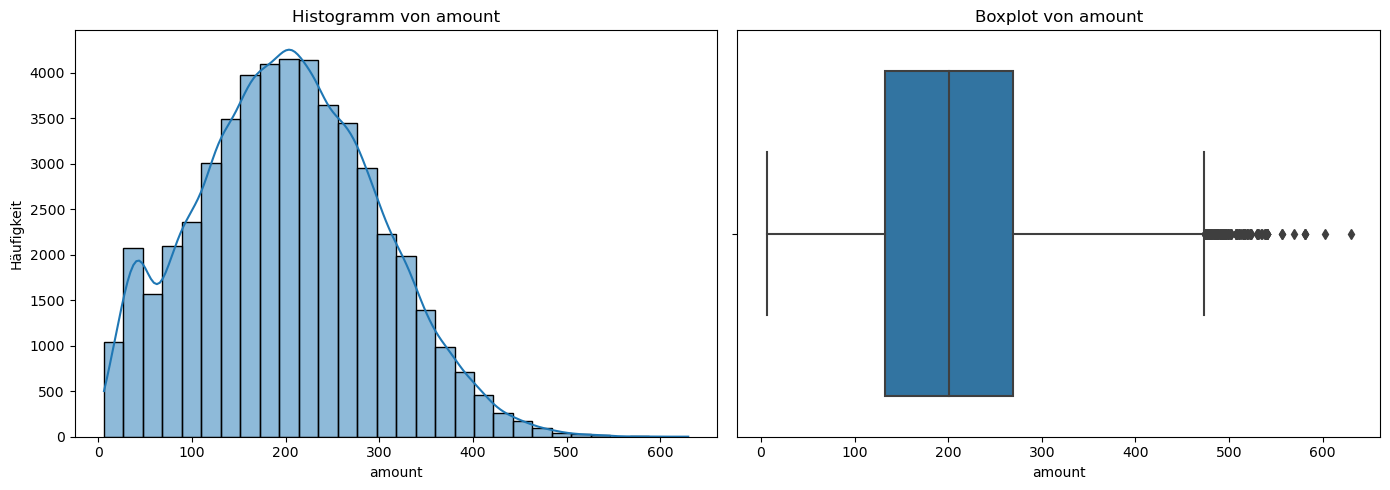

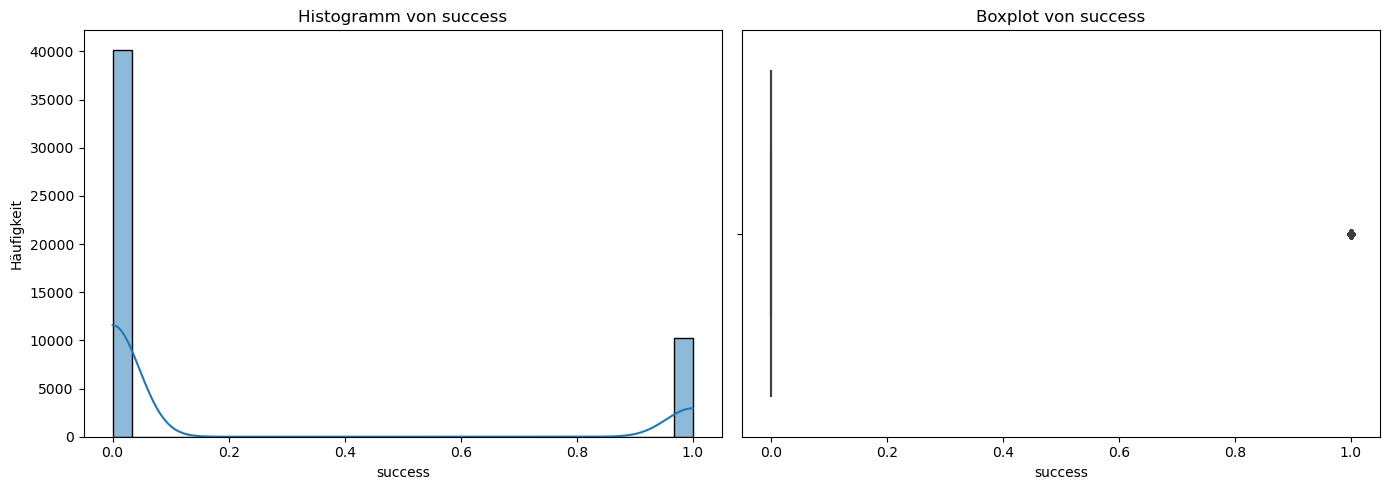

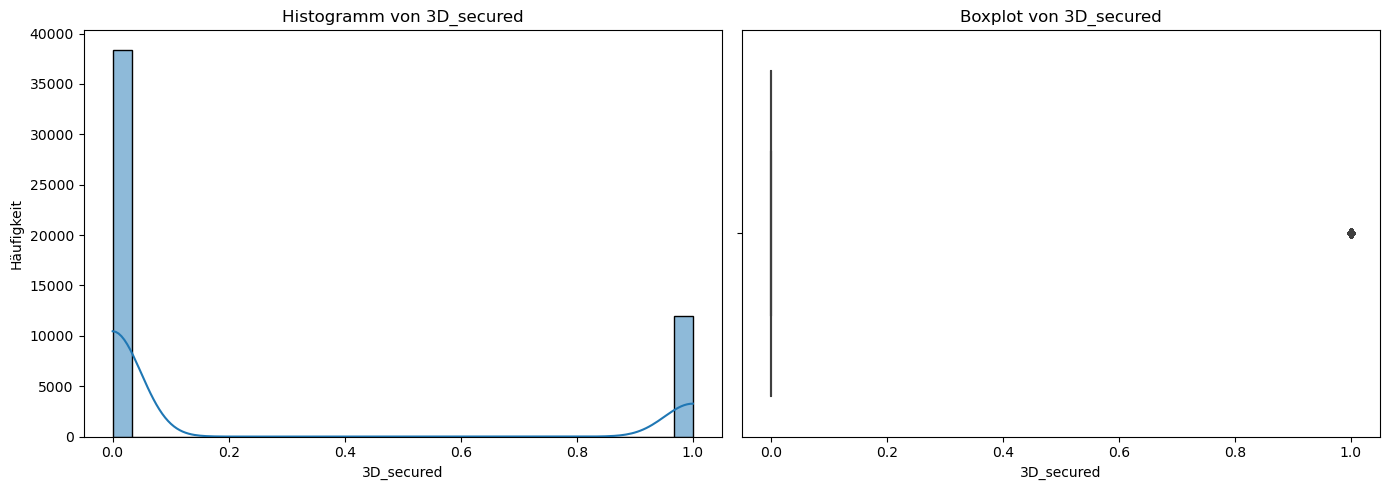

In [56]:
for col in numeric_cols:
    plt.figure(figsize=(14, 5))
    
    # Histogramm 
    plt.subplot(1, 2, 1)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Histogramm von {col}')
    plt.xlabel(col)
    plt.ylabel('Häufigkeit')
    
    # Boxplot to detect outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot von {col}')
    
    plt.tight_layout()
    plt.show()

In [70]:
x = df['amount'].dropna()

print(f"Skewness       : {skew(x):.2f}")
print(f"Excess kurtosis: {kurtosis(x, fisher=True):.2f}")

Skewness       : 0.19
Excess kurtosis: -0.34


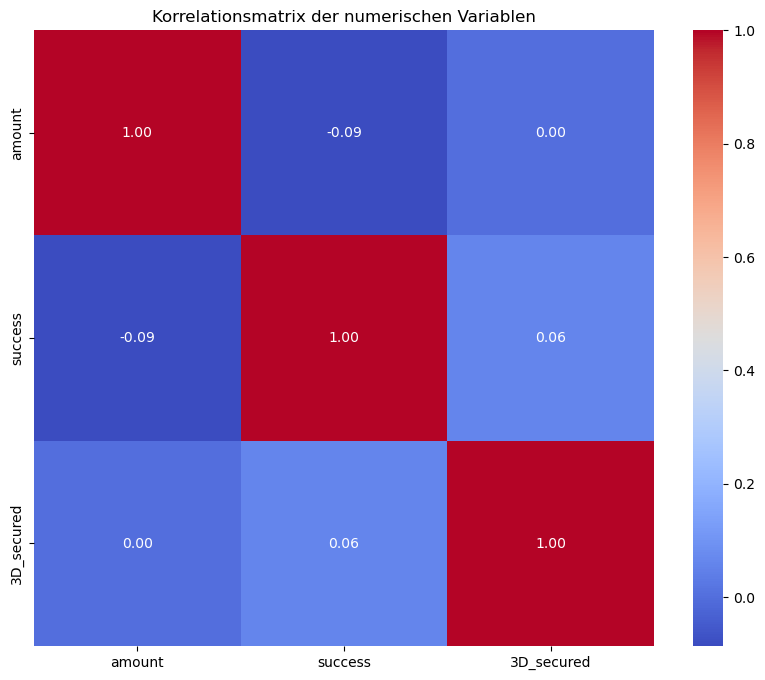

In [57]:
# Correlation matrix as heatmap
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korrelationsmatrix der numerischen Variablen')
plt.show()

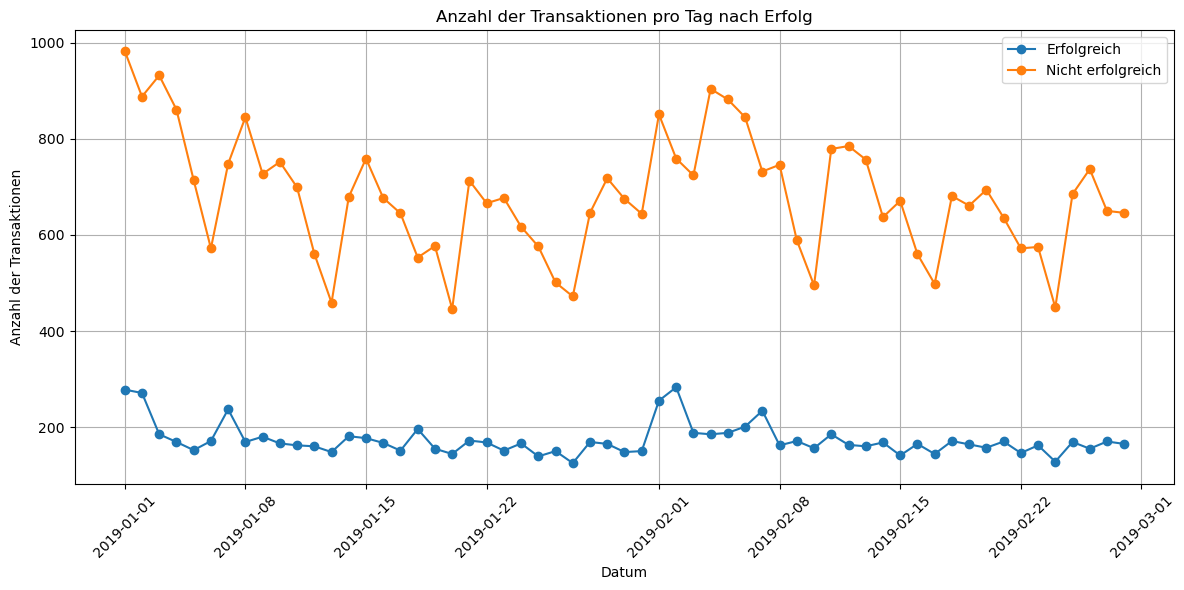

In [58]:
# Convert 'tmsp' in a Datetime-Format:
df['tmsp'] = pd.to_datetime(df['tmsp'], errors='coerce')

# Exctract date
df['date'] = df['tmsp'].dt.date

# Group by 'date' and 'success', count transactions 
daily_counts_success = df.groupby(['date', 'success']).size().unstack(fill_value=0)

# Plot: Count of Transactions per day grouped by 'success'
plt.figure(figsize=(12, 6))
plt.grid(True)
plt.plot(daily_counts_success.index, daily_counts_success[1], marker='o', label='Erfolgreich')
plt.plot(daily_counts_success.index, daily_counts_success[0], marker='o', label='Nicht erfolgreich')
plt.xlabel('Datum')
plt.ylabel('Anzahl der Transaktionen')
plt.title('Anzahl der Transaktionen pro Tag nach Erfolg')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

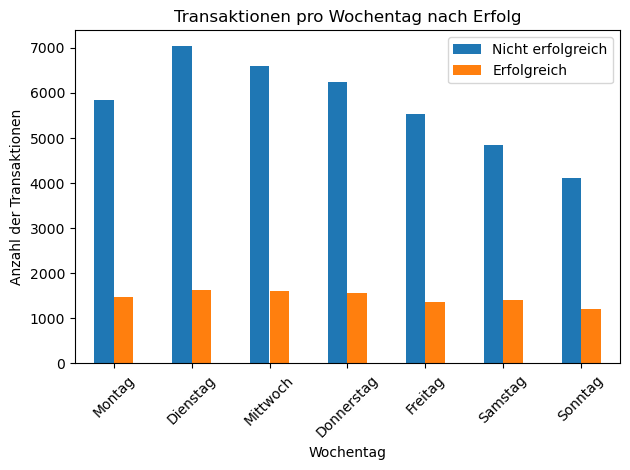

In [59]:
# Convert 'tmsp' in a Datetime-Format:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract weekday
df['weekday'] = df['date'].dt.dayofweek  # 0=Montag, ..., 6=Sonntag
weekday_map = {
    0: 'Montag', 1: 'Dienstag', 2: 'Mittwoch',
    3: 'Donnerstag', 4: 'Freitag', 5: 'Samstag', 6: 'Sonntag'
}
df['weekday_name'] = df['weekday'].map(weekday_map)

# Groupby and count
counts = (
    df
    .groupby(['weekday_name', 'success'])
    .size()
    .unstack(fill_value=0)   
    .rename(columns={False: 'Nicht erfolgreich', True: 'Erfolgreich'})
)

# Order
ordered_days = ['Montag','Dienstag','Mittwoch','Donnerstag','Freitag','Samstag','Sonntag']
counts = counts.reindex(ordered_days)

# Plot
plt.figure(figsize=(10,6))
counts.plot(kind='bar', stacked=False)
plt.xlabel('Wochentag')
plt.ylabel('Anzahl der Transaktionen')
plt.title('Transaktionen pro Wochentag nach Erfolg')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

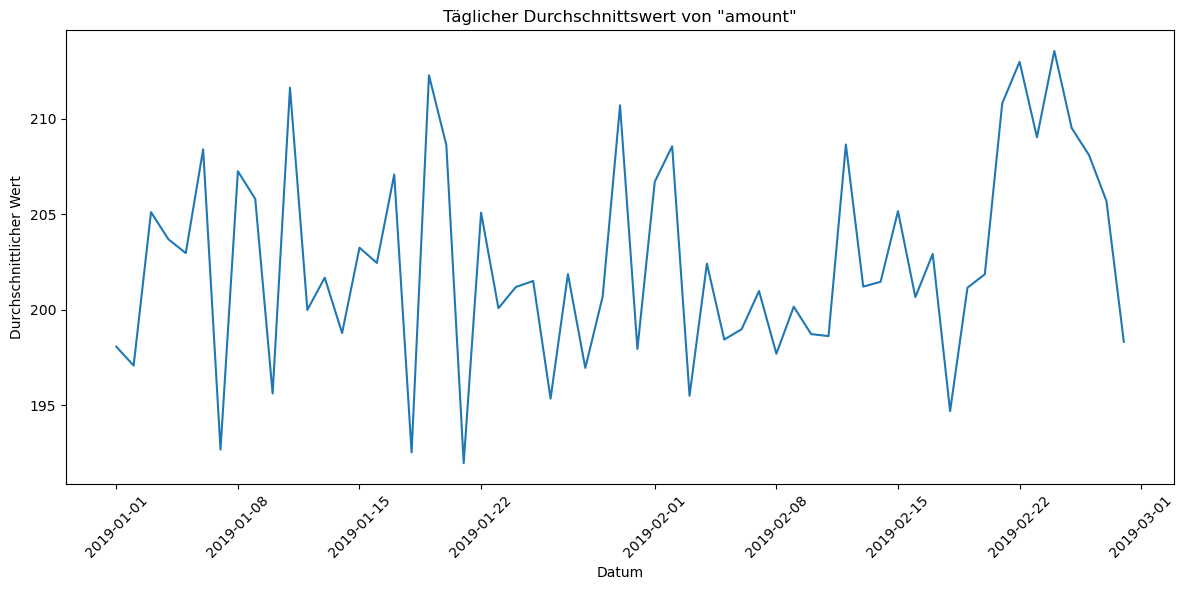

In [60]:
# Daily mean of "amount"
if 'amount' in df.columns:
    daily_mean = df.groupby('date')['amount'].mean()

    plt.figure(figsize=(12, 6))
    sns.lineplot(x=daily_mean.index, y=daily_mean.values)
    plt.xlabel('Datum')
    plt.ylabel('Durchschnittlicher Wert')
    plt.title('Täglicher Durchschnittswert von "amount"')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

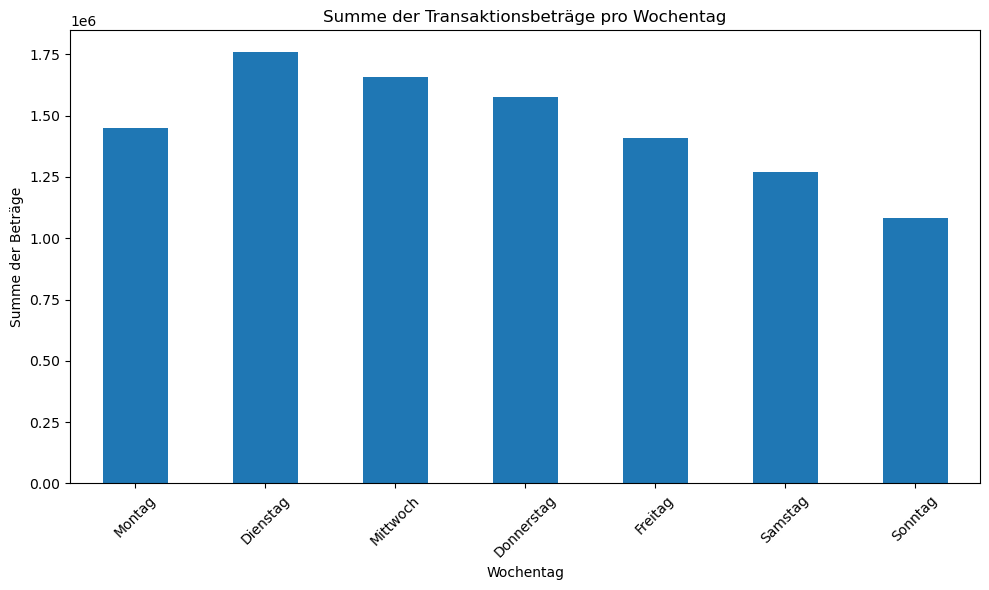

In [61]:
# Order
ordered_days = ['Montag','Dienstag','Mittwoch','Donnerstag','Freitag','Samstag','Sonntag']

# Sum of amout per weekday
amount_sum = (
    df
    .groupby('weekday_name')['amount']
    .sum()
    .reindex(ordered_days)
)

# Plot
plt.figure(figsize=(10,6))
amount_sum.plot(kind='bar')
plt.xlabel('Wochentag')
plt.ylabel('Summe der Beträge')
plt.title('Summe der Transaktionsbeträge pro Wochentag')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

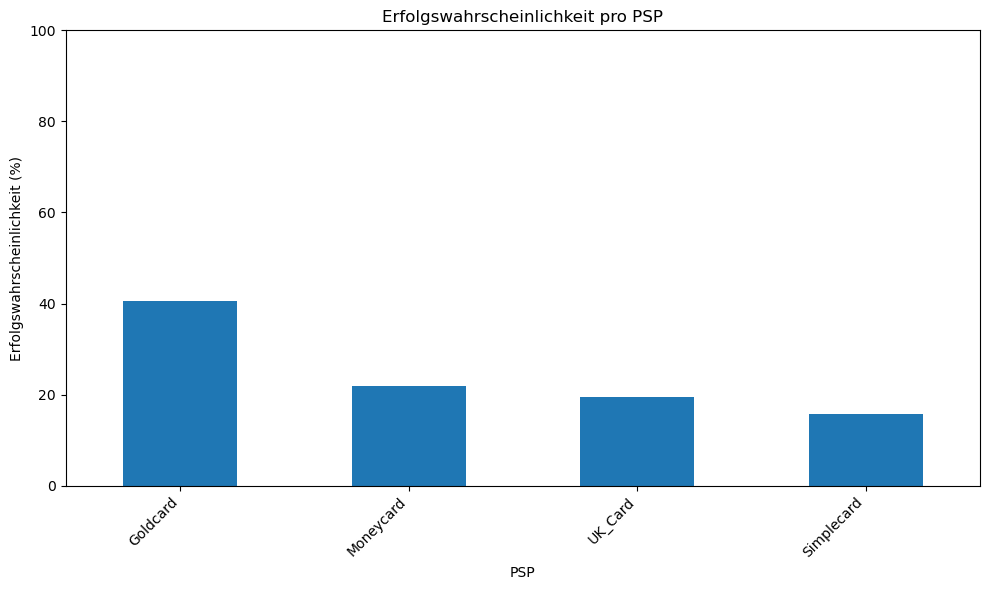

In [62]:
# Calculate successrate per PSP
success_rate = df.groupby('PSP')['success'].mean()

# Order
success_rate = success_rate.sort_values(ascending=False)

# Convert to percent
success_rate_pct = success_rate * 100

# Plot
plt.figure(figsize=(10,6))
success_rate_pct.plot(kind='bar')
plt.xlabel('PSP')
plt.ylabel('Erfolgswahrscheinlichkeit (%)')
plt.title('Erfolgswahrscheinlichkeit pro PSP')
plt.xticks(rotation=45, ha='right')
plt.ylim(0,100)
plt.tight_layout()
plt.show()

In [63]:
from ydata_profiling import ProfileReport

# Create a profilereport with ydata-profiling
profile = ProfileReport(df, title="Datenqualitätsreport", explorative=True)
# Save Report as HTML 
profile.to_file(r'C:\Users\miria\PSP\data\processed\data_quality_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  6.11it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]